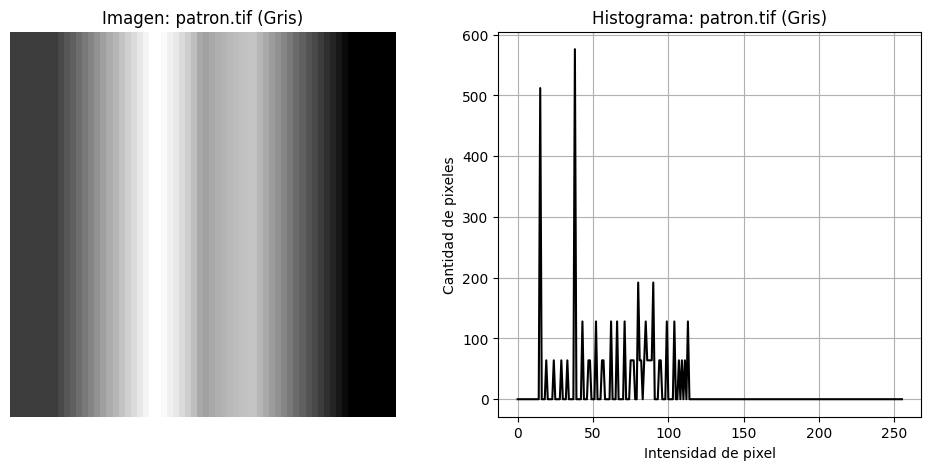

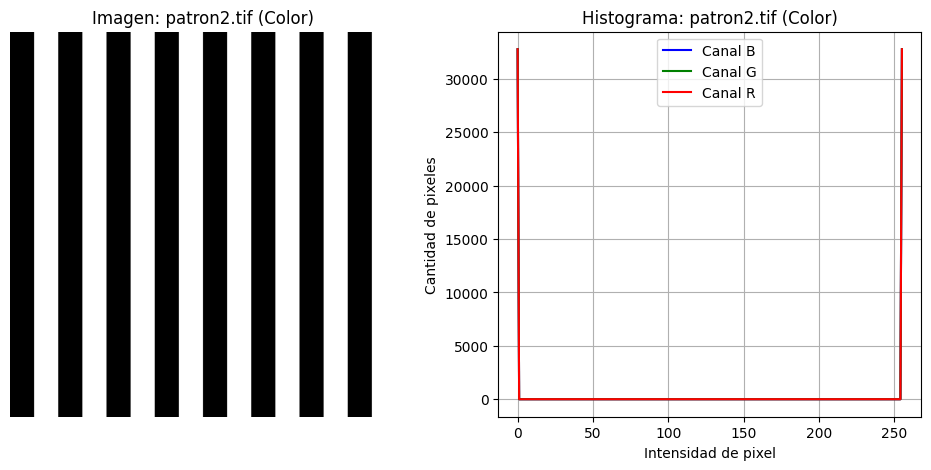

In [11]:
### 1- Cargue y visualice la imagenes patron2.tif y patron.tif (a esta ultima utilıcela a escala de grises).

import cv2
import matplotlib.pyplot as plt
import numpy as np

def analizar_imagen(img, titulo, es_color=False):
    # Verificación de seguridad para que no explote si la ruta falla
    if img is None:
        print(f"Error: No se pudo leer {titulo}. Verifica que la terminal esté en la carpeta 'Practica'.")
        return

    plt.figure(figsize=(12, 5))

    # Visualización
    plt.subplot(1, 2, 1)
    if es_color:
        # Convertir BGR (OpenCV) a RGB (Matplotlib)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(f'Imagen: {titulo}')
    plt.axis('off')

    # Histograma
    plt.subplot(1, 2, 2)
    if es_color:
        colores = ('b', 'g', 'r')
        for i, col in enumerate(colores):
            hist = cv2.calcHist([img], [i], None, [256], [0, 256])
            plt.plot(hist, color=col, label=f'Canal {col.upper()}')
    else:
        hist = cv2.calcHist([img], [0], None, [256], [0, 256])
        plt.plot(hist, color='black')
    
    plt.title(f'Histograma: {titulo}')
    plt.xlabel('Intensidad de pixel')
    plt.ylabel('Cantidad de pixeles')
    plt.legend() if es_color else None
    plt.grid(True)
    plt.show()

# RUTAS MANUALES (Funcionan si ejecutas DESDE la carpeta 'Practica')
img1 = '../../imagenes/patron.tif'
img2 = '../../imagenes/patron2.tif'

# 1. Cargar las imágenes
img_patron = cv2.imread(img1, cv2.IMREAD_GRAYSCALE)
img_patron2 = cv2.imread(img2) # Corregido: antes tenías 'imp_patron2'

analizar_imagen(img_patron, "patron.tif (Gris)")
analizar_imagen(img_patron2, "patron2.tif (Color)", es_color=True)


La imagen de patron.tif a simple vista es un degradado de colores pero al cargarla en escala de grises nos revela su estructura interna. 
En lugar de una montaña suave y continua vemos una serie de picos aislados, esto indica que la imagen no es un degradado analogico perfecto, sino que está compuesta por franjas de colores sólidos con saltos bruscos de intensidad
Intensidad de píxel de 0 a 120 aprox. Esto significa que, aunque vemos colores (rojo, verde, azul), su equivalencia en niveles de gris es bastante oscura. No hay blancos ni grises claros en esta conversión.
Expectativa vs. Realidad: Uno podría esperar un histograma plano (distribución uniforme), pero la realidad es que hay intensidades que se repiten mucho más que otras (los picos más altos).

La imagen de patron2.tif es un patrón de barras verticales (blanco y negro). El histograma nos dice cómo es una imagen de alto contraste:
Bimodalidad extrema: Solo vemos dos grandes picos. Uno en el nivel 0 (negro absoluto) y otro en el nivel 255 (blanco absoluto).
Superposición de canales: Los canales R, G y B están perfectamente solapados (la línea se ve roja porque es la última que se graficó).
Simetría: Los dos picos tienen una altura similar, lo que nos indica que la cantidad de píxeles negros es prácticamente igual a la cantidad de píxeles blancos (las barras tienen el mismo ancho).
Expectativa vs. Realidad: Aquí la realidad coincide al 100% con la expectativa: una imagen de barras B/N solo debe tener información en los extremos.


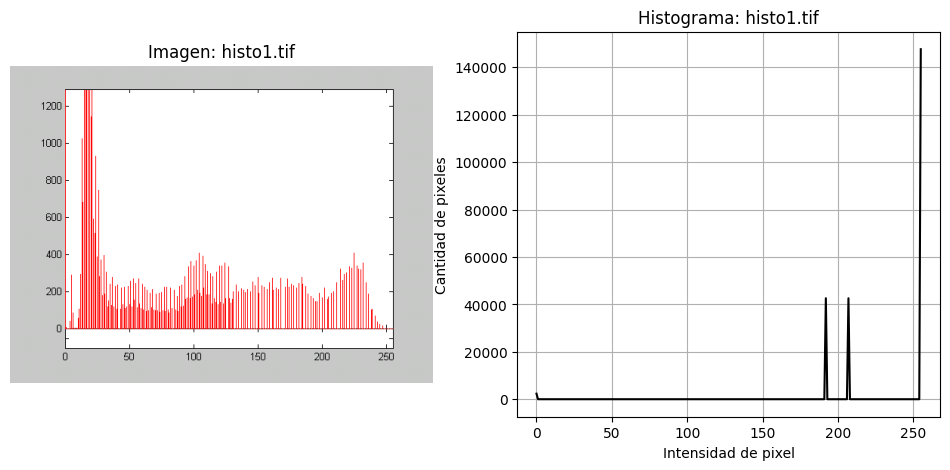

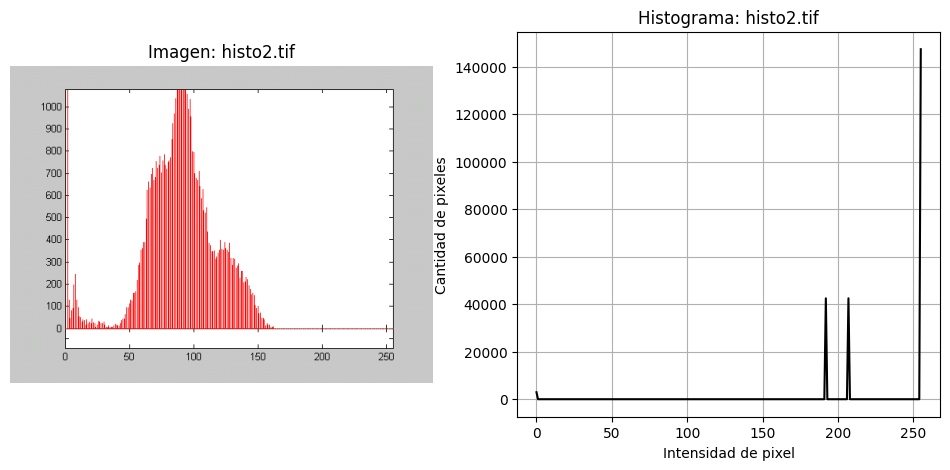

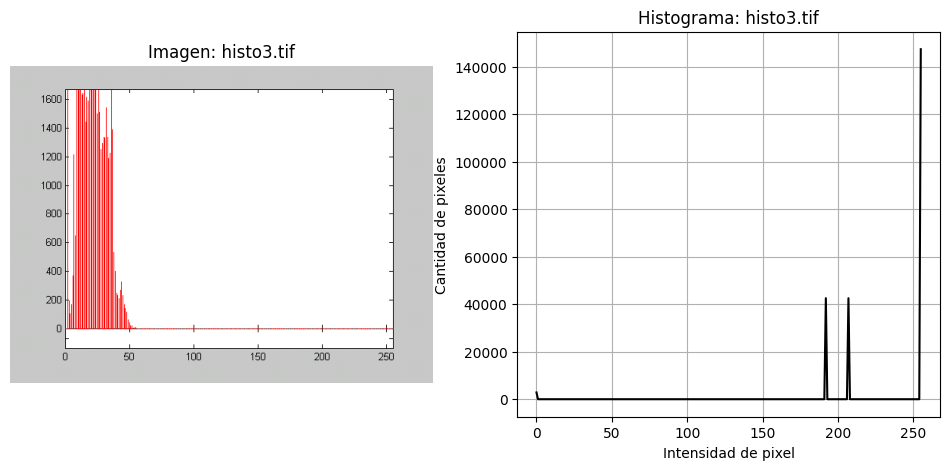

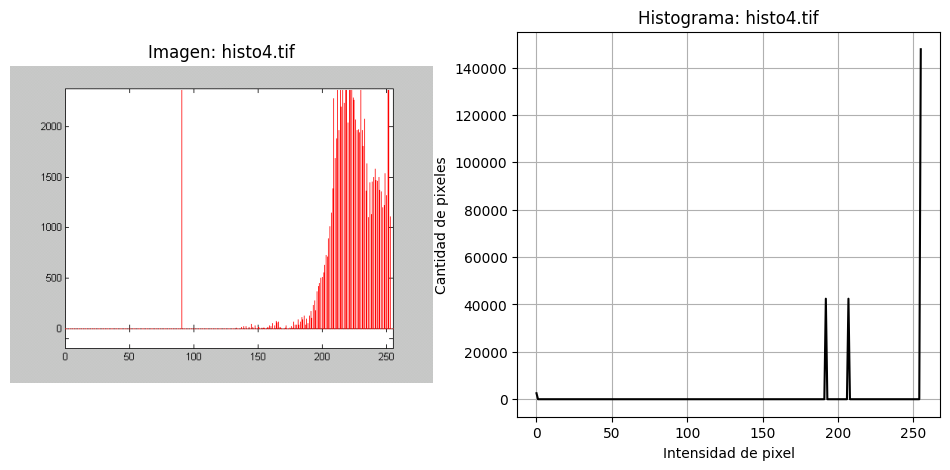

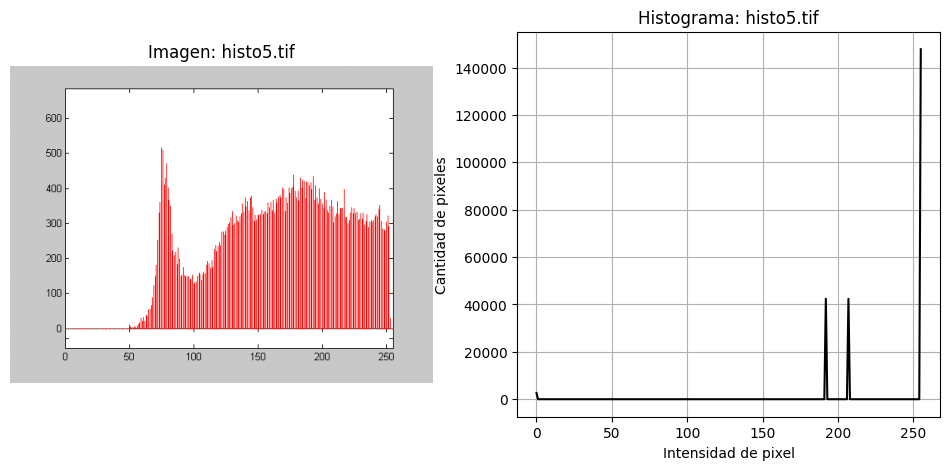

In [12]:
#2 - archivos histo1.tif, histo2.tif, histo3.tif, histo4.tif e histo5.tif
img3 = '../../imagenes/histo1.tif'
img4 = '../../imagenes/histo2.tif'
img5 = '../../imagenes/histo3.tif'
img6 = '../../imagenes/histo4.tif'
img7 = '../../imagenes/histo5.tif'

img_patron3 = cv2.imread(img3)
img_patron4 = cv2.imread(img4)
img_patron5 = cv2.imread(img5)
img_patron6 = cv2.imread(img6)
img_patron7 = cv2.imread(img7)

analizar_imagen(img_patron3, "histo1.tif")
analizar_imagen(img_patron4, "histo2.tif")
analizar_imagen(img_patron5, "histo3.tif")
analizar_imagen(img_patron6, "histo4.tif")
analizar_imagen(img_patron7, "histo5.tif")

CLARA U OBSCURA
Si los picos estan a la izquierda -> oscura, predominan los negros
Si los picos estan a la derecha -> clara, predominan los blancos

CONTRASTE
Histograma angosto: Bajo contraste
Histograma ancho: Alto contraste

PICOS SOBRE LOS OBJETOS
Un solo pico la imagen es uniforme. Ej un cielo despejado
Dos picos separados, objeto claro sobre fondo oscuro
Histograma plano: mucha variedad de detalles

ESTADISTICAS DE LOS HISTOGRAMAS

Media -> Brillo
Varianza-> Contraste
Asimetria -> Asimetría positiva (la cola se extiende hacia los claros). La masa de la imagen es oscura. Asimetría negativa (la cola se extiende hacia los negros). La masa de la imagen es clara.
Energia -> que tan homogenea es la imagen
Entropia -> Entropia alta: Mucho detalle - Entropia Baja: poco detalle

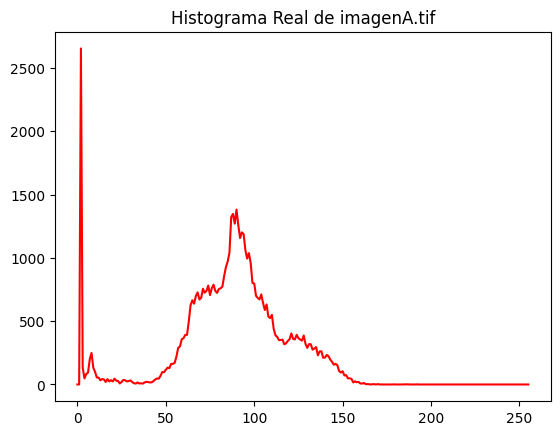

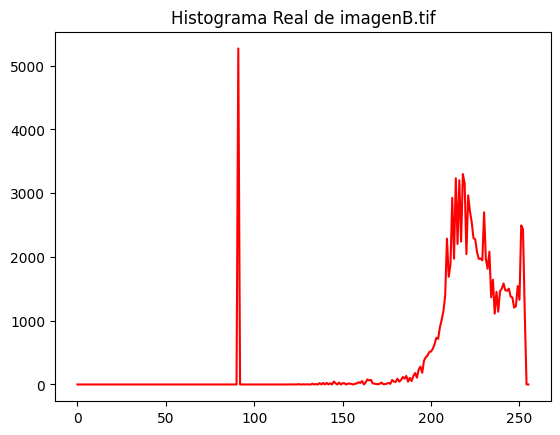

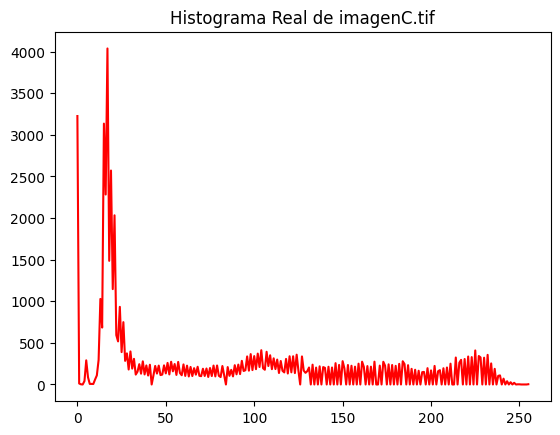

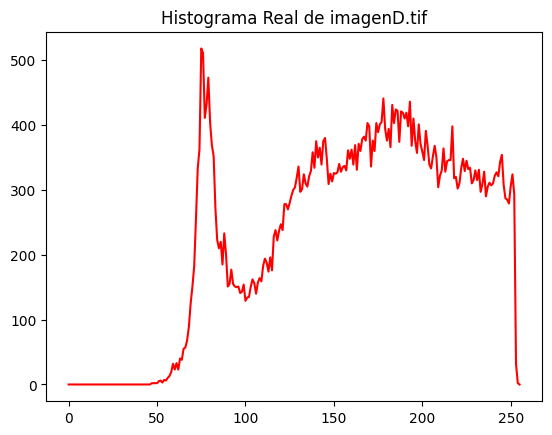

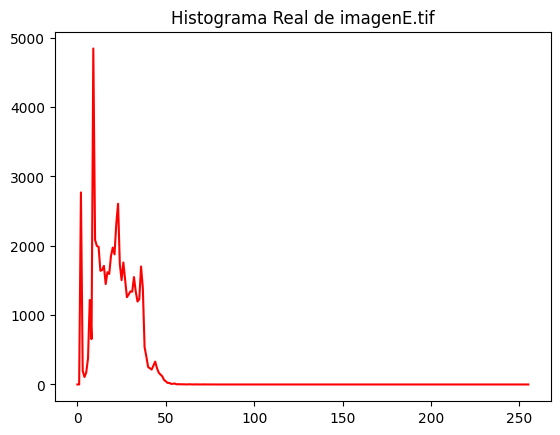

In [13]:
# Carga las imágenes reales 
nombres = ['imagenA.tif', 'imagenB.tif', 'imagenC.tif', 'imagenD.tif', 'imagenE.tif']

for n in nombres:
    img_real = cv2.imread(f'../../imagenes/{n}', cv2.IMREAD_GRAYSCALE)
    # Calculá el histograma de la foto real
    hist_real = cv2.calcHist([img_real], [0], None, [256], [0, 256])
    
    # Graficá para comparar
    plt.figure()
    plt.plot(hist_real, color='red') # Usamos rojo para que se parezca a los archivos histoX.tif
    plt.title(f"Histograma Real de {n}")
    plt.show()

C:\Users\santi\AppData\Local\Temp\ipykernel_26196\2075093067.py:45: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_real.ravel(), 256, [0, 256], color='red', histtype='step')


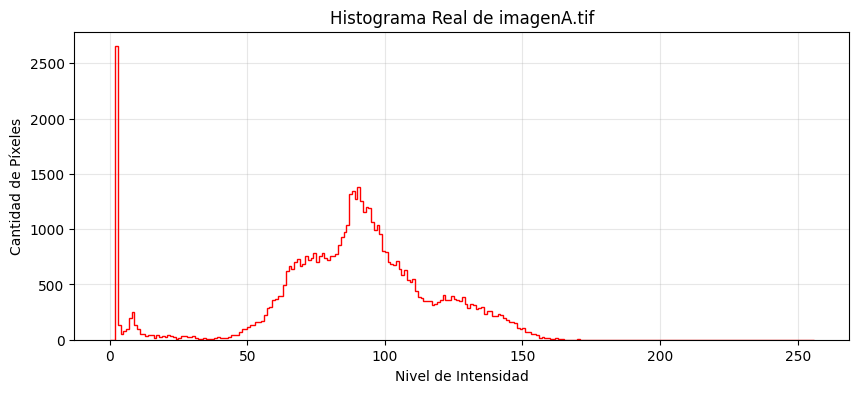

--- Análisis de imagenA.tif ---
Media: 87.23 | Varianza: 1010.37 | Asimetría: -0.79
Energía: 0.01327 | Entropía: 6.59
--------------------------------------------------


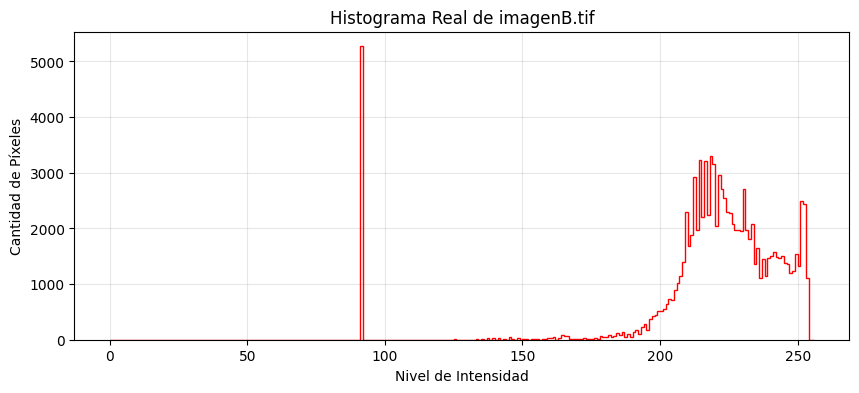

--- Análisis de imagenB.tif ---
Media: 218.15 | Varianza: 1089.35 | Asimetría: -2.74
Energía: 0.02022 | Entropía: 5.86
--------------------------------------------------


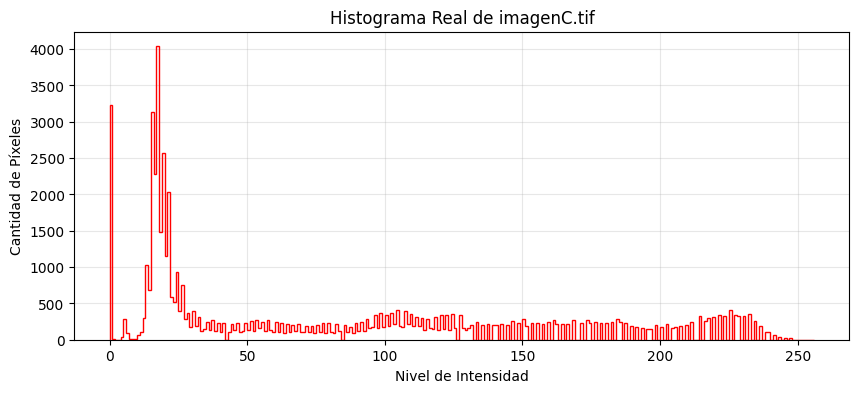

--- Análisis de imagenC.tif ---
Media: 77.66 | Varianza: 5079.12 | Asimetría: 0.79
Energía: 0.01895 | Entropía: 6.74
--------------------------------------------------


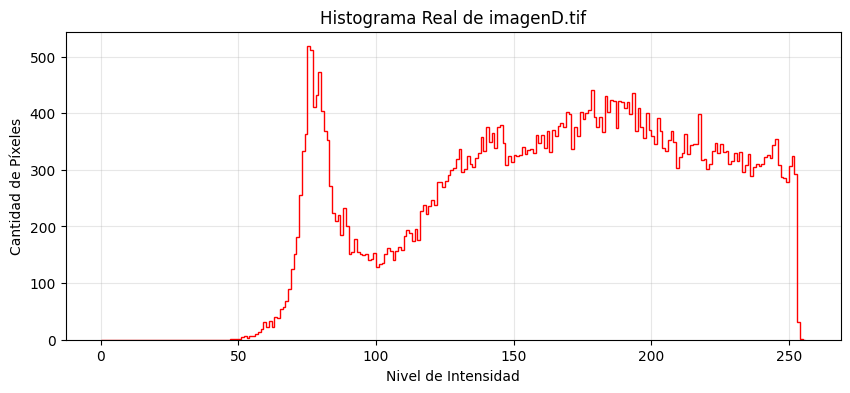

--- Análisis de imagenD.tif ---
Media: 165.94 | Varianza: 2663.74 | Asimetría: -0.24
Energía: 0.00572 | Entropía: 7.51
--------------------------------------------------


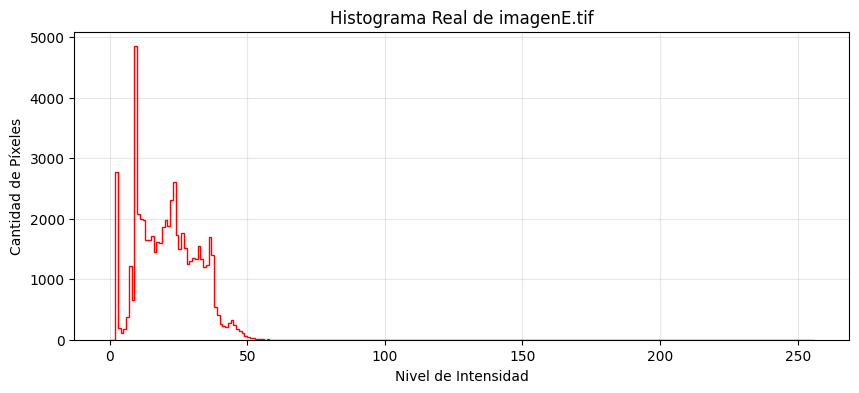

--- Análisis de imagenE.tif ---
Media: 20.88 | Varianza: 114.58 | Asimetría: 0.34
Energía: 0.03184 | Entropía: 5.20
--------------------------------------------------


In [19]:
def calcular_estadisticas(img):
    # 1. Calcular histograma y normalizarlo para obtener la PDF (p)
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    p = hist.flatten() / img.size
    
    # 2. Niveles de intensidad (0 a 255)
    L = np.arange(256)
    
    # --- Cálculos Estadísticos ---
    # Media (Brillo)
    media = np.sum(L * p)
    
    # Varianza (Contraste)
    varianza = np.sum(((L - media)**2) * p)
    std_dev = np.sqrt(varianza)
    
    # Asimetría (Sesgo) - Usamos un epsilon 1e-6 para evitar división por 0
    asimetria = np.sum(((L - media)**3) * p) / (std_dev**3 + 1e-6)
    
    # Energía (Uniformidad)
    energia = np.sum(p**2)
    
    # Entropía (Información/Detalle) - Evitamos log(0) con 1e-10
    entropia = -np.sum(p * np.log2(p + 1e-10))
    
    # Retornamos los valores como una tupla
    return media, varianza, asimetria, energia, entropia

# Asegúrate de que 'nombres' y 'calcular_estadisticas' estén definidos arriba
for n in nombres:
    ruta = f'../../imagenes/{n}'
    img_real = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    
    if img_real is None:
        print(f"No se pudo cargar {n}")
        continue

    # 1. Calculamos las estadísticas usando tu función
    m, v, asim, en, ent = calcular_estadisticas(img_real)
    
    # 2. Graficamos el HISTOGRAMA (no la imagen)
    plt.figure(figsize=(10, 4))
    
    # Para que se vea como las barritas rojas de los archivos histoX.tif:
    plt.hist(img_real.ravel(), 256, [0, 256], color='red', histtype='step')
    
    plt.title(f"Histograma Real de {n}")
    plt.xlabel("Nivel de Intensidad")
    plt.ylabel("Cantidad de Píxeles")
    plt.grid(True, alpha=0.3)
    plt.show()

    # 3. Imprimimos los resultados para el análisis
    print(f"--- Análisis de {n} ---")
    print(f"Media: {m:.2f} | Varianza: {v:.2f} | Asimetría: {asim:.2f}")
    print(f"Energía: {en:.5f} | Entropía: {ent:.2f}")
    print("-" * 50)


⌛ Procesando imagenA.tif...


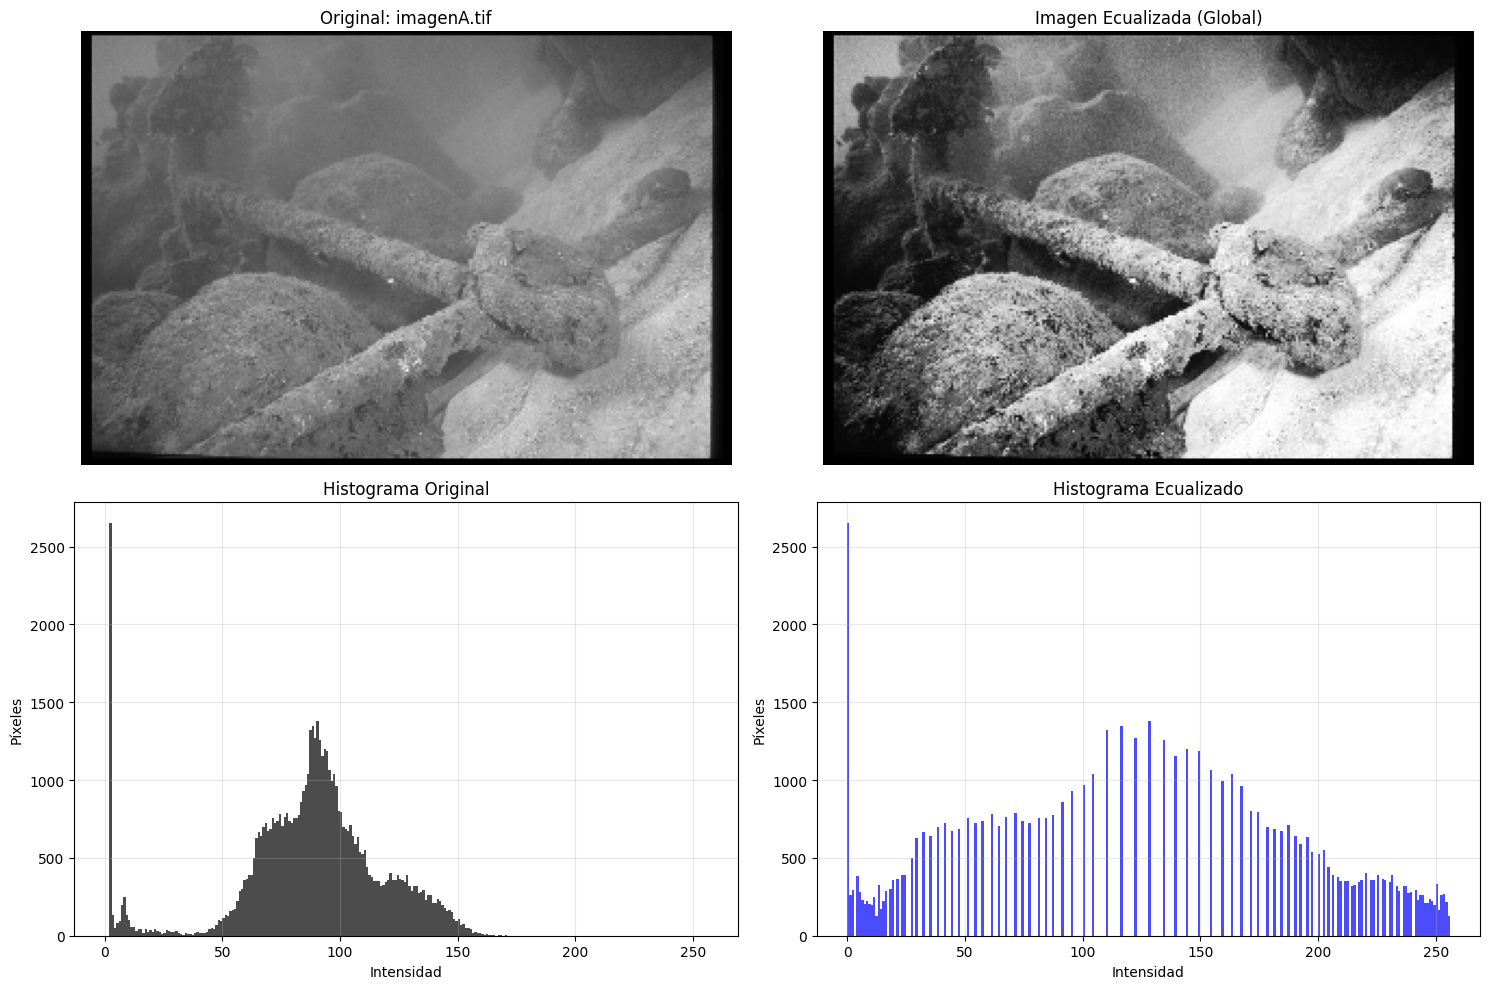

⌛ Procesando imagenB.tif...


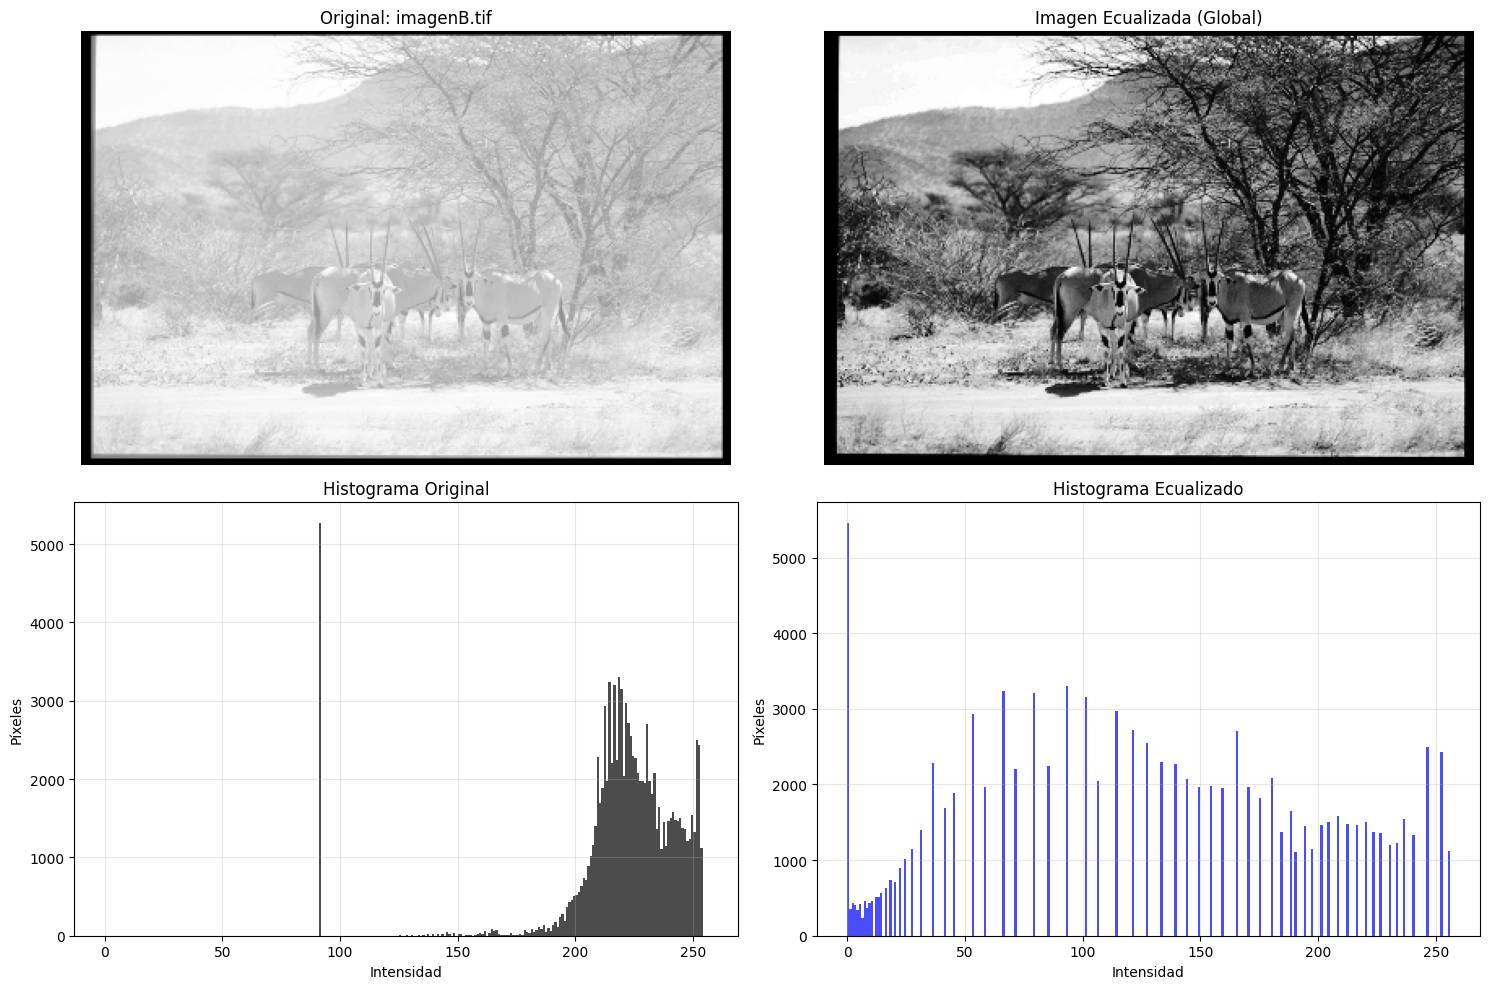

⌛ Procesando imagenC.tif...


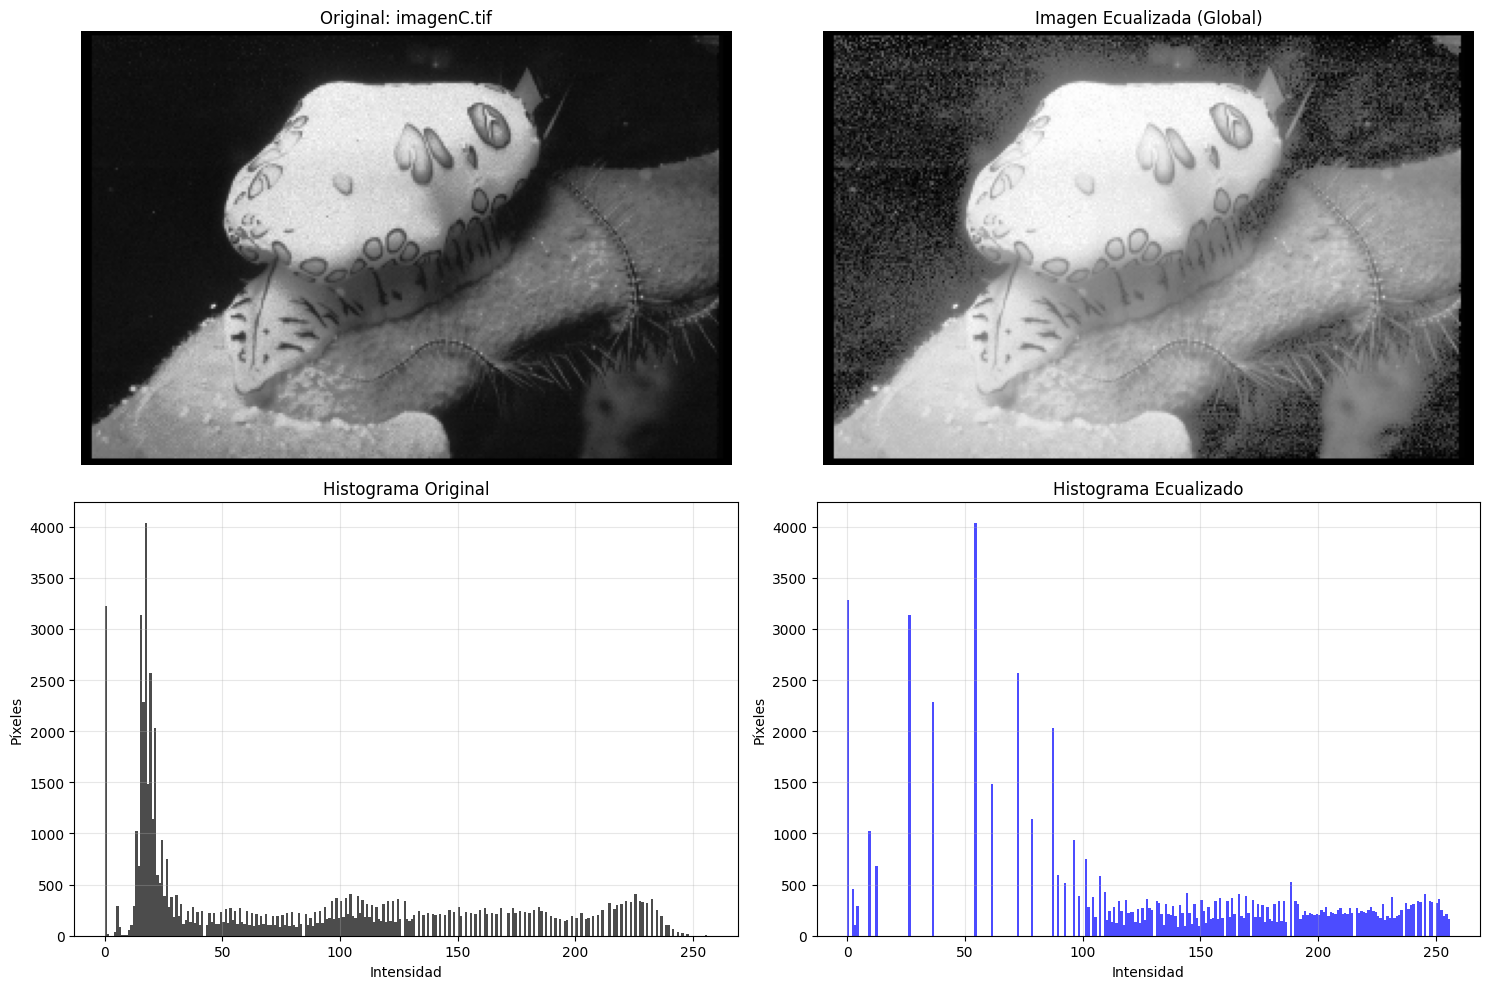

⌛ Procesando imagenD.tif...


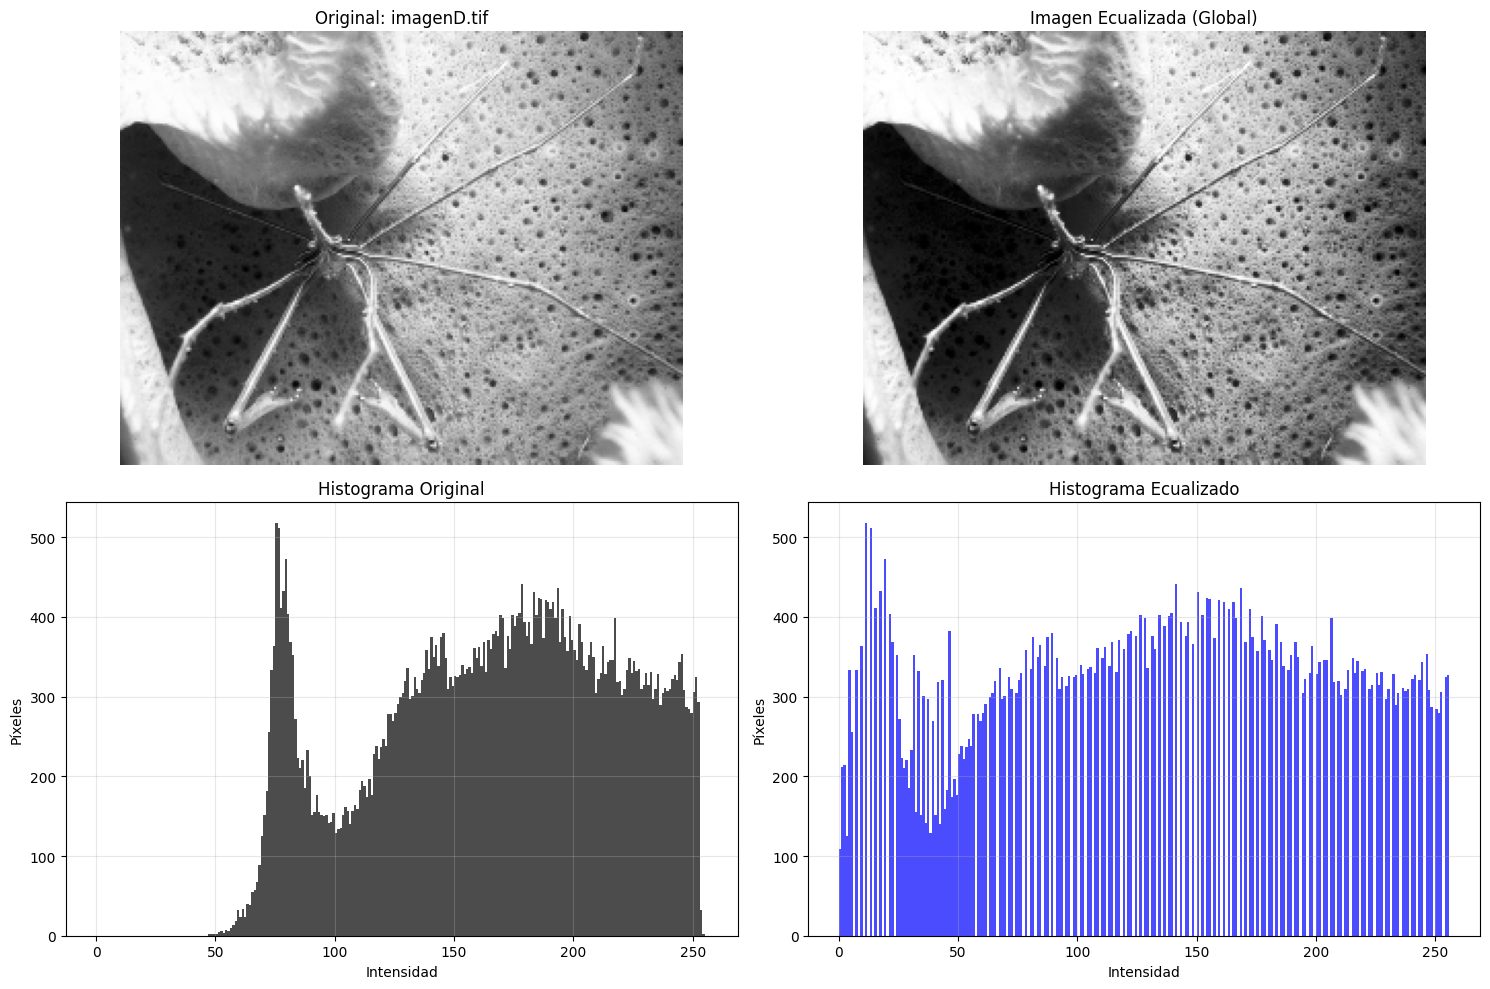

⌛ Procesando imagenE.tif...


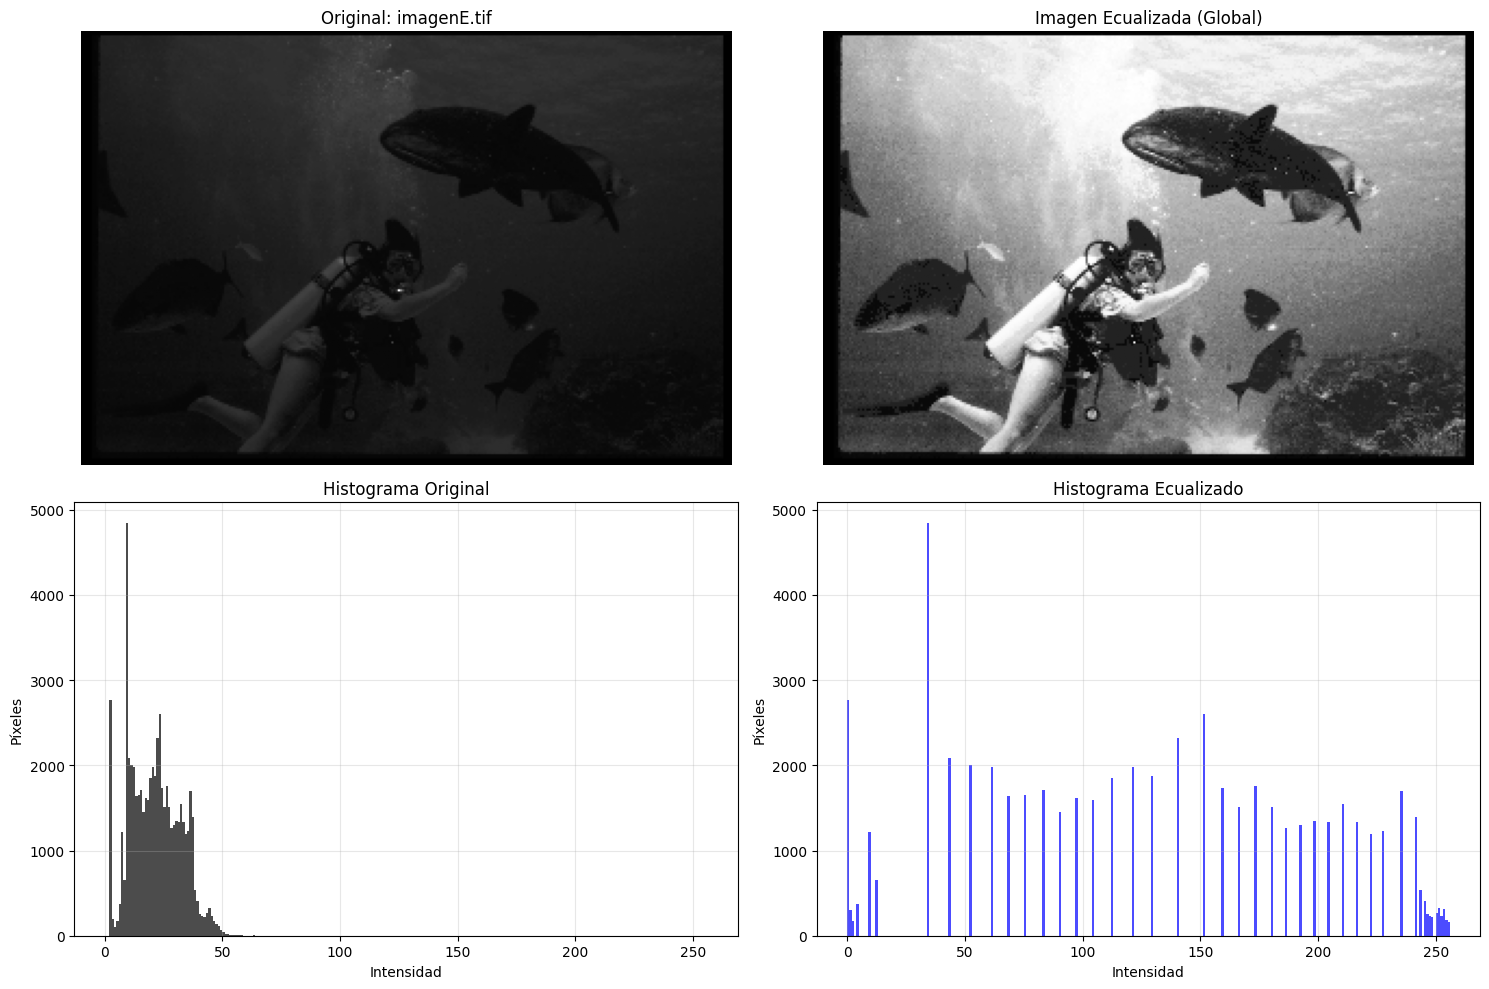

In [21]:
def ejercicio_ecualizacion(ruta_imagen):
    # 1. Cargar imagen en escala de grises
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print(f"❌ Error: No se pudo cargar la imagen en {ruta_imagen}")
        return

    # 2. Realizar la ecualización del histograma
    equ = cv2.equalizeHist(img)

    # 3. Configurar la visualización (2 filas x 2 columnas)
    plt.figure(figsize=(15, 10))

    # --- Fila 1: Imágenes ---
    # Imagen Original
    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Original: {ruta_imagen.split("/")[-1]}')
    plt.axis('off')

    # Imagen Ecualizada
    plt.subplot(2, 2, 2)
    plt.imshow(equ, cmap='gray')
    plt.title('Imagen Ecualizada (Global)')
    plt.axis('off')

    # --- Fila 2: Histogramas (Corregidos sin Warnings) ---
    # Histograma Original
    plt.subplot(2, 2, 3)
    plt.hist(img.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
    plt.title('Histograma Original')
    plt.xlabel('Intensidad')
    plt.ylabel('Píxeles')
    plt.grid(True, alpha=0.3)

    # Histograma Ecualizado
    plt.subplot(2, 2, 4)
    plt.hist(equ.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
    plt.title('Histograma Ecualizado')
    plt.xlabel('Intensidad')
    plt.ylabel('Píxeles')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- Ejecución del Análisis ---
# Usamos la lista de nombres que ya tenías definida
ruta_base = '../../imagenes/'
for n in nombres:
    print(f"⌛ Procesando {n}...")
    ejercicio_ecualizacion(f"{ruta_base}{n}")